In [ ]:
import os
from keras.models import Model
from keras.optimizers import Adam
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import Dense, Dropout, Flatten
from pathlib import Path
import numpy as np

## Downloading and preparing the dataset

In [ ]:
!wget http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz

In [ ]:
!tar xzvf food-101.tar.gz

In [ ]:
BATCH_SIZE = 8

train_generator = ImageDataGenerator(rotation_range=90,
                                     brightness_range=[0.1, 0.7],
                                     width_shift_range=0.5,
                                     height_shift_range=0.5,
                                     horizontal_flip=True,
                                     vertical_flip=True,
                                     validation_split=0.15,
                                     preprocessing_function=preprocess_input) # VGG16 preprocessing

test_generator = ImageDataGenerator(preprocessing_function=preprocess_input) # VGG16 preprocessing

In [ ]:
# # Move data from images to images/train or images/test:
# import shutil
# from collections import defaultdict
# import json
# from pathlib import Path
# import os

# def split_dataset(root_food_path):
#     """Takes in the path for food-101 directory and creates train/test dirs of images"""
#     data_paths = {
#         'train': root_food_path/'meta/train.json',
#         'test': root_food_path/'meta/test.json'
#     }
#     for data_type, meta_path in data_paths.items():
#         # Make the train/test dirs
#         os.makedirs(root_food_path/data_type, exist_ok=True)

#         # Read the meta files.
#         # These are loaded as a dict of food names with a list of image paths
#         # E.g. {"<food_name>": ["<food_name>/<image_num>", ...], ...}
#         food_images = json.load(open(meta_path, 'r'))

#         for food_name, image_paths in food_images.items():
#             # Make food dir in train/test dir
#             os.makedirs(root_food_path/data_type/food_name, exist_ok=True)

#             # Move images from food-101/images to food-101/train (or test)
#             for image_path in image_paths:
#                 image_path = image_path + '.jpg'
                # shutil.move(root_food_path/'images'/image_path, root_food_path/data_type/image_path)


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

def split_dataset(dataset_dir, train_dir, test_dir, test_size=0.2, random_state=42):
    # Create train and test directories if they don't exist
    if not os.path.exists(train_dir):
        os.makedirs(train_dir)
    if not os.path.exists(test_dir):
        os.makedirs(test_dir)

    # Iterate over each class directory
    for class_name in os.listdir(dataset_dir):
        class_dir = os.path.join(dataset_dir, class_name)
        if os.path.isdir(class_dir):
            # Get list of files in class directory
            files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
            # Split files into train and test sets
            train_files, test_files = train_test_split(files, test_size=test_size, random_state=random_state)
            # Create train and test directories for the current class
            train_class_dir = os.path.join(train_dir, class_name)
            test_class_dir = os.path.join(test_dir, class_name)
            if not os.path.exists(train_class_dir):
                os.makedirs(train_class_dir)
            if not os.path.exists(test_class_dir):
                os.makedirs(test_class_dir)
            # Move train files
            for train_file in train_files:
                shutil.copy(os.path.join(class_dir, train_file), os.path.join(train_class_dir, train_file))
            # Move test files
            for test_file in test_files:
                shutil.copy(os.path.join(class_dir, test_file), os.path.join(test_class_dir, test_file))

# Example usage:
dataset_dir = "path/to/dataset"
train_dir = "path/to/train"
test_dir = "path/to/test"
split_dataset(dataset_dir, train_dir, test_dir, test_size=0.2, random_state=42)


In [ ]:
from pathlib import Path

download_dir = Path('/content/')
# split_dataset(download_dir/'food-101')

In [ ]:
train_data_dir = download_dir/'drive/MyDrive/pose Estimation Dataset/train'
test_data_dir = download_dir/'drive/MyDrive/pose Estimation Dataset/test'

class_subset = sorted(os.listdir(download_dir/'drive/MyDrive/pose Estimation'))[:10] # Using only the first 10 classes

traingen = train_generator.flow_from_directory(train_data_dir,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               classes=class_subset,
                                               subset='training',
                                               batch_size=BATCH_SIZE,
                                               shuffle=True,
                                               seed=42)

validgen = train_generator.flow_from_directory(train_data_dir,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               classes=class_subset,
                                               subset='validation',
                                               batch_size=BATCH_SIZE,
                                               shuffle=True,
                                               seed=42)

testgen = test_generator.flow_from_directory(test_data_dir,
                                             target_size=(224, 224),
                                             class_mode=None,
                                             classes=class_subset,
                                             batch_size=1,
                                             shuffle=False,
                                             seed=42)

Found 290 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 87 images belonging to 3 classes.


## Using Pre-trained Layers for Feature Extraction

In [ ]:
def create_model(input_shape, n_classes, optimizer='rmsprop', fine_tune=0):
    """
    Compiles a model integrated with VGG16 pretrained layers

    input_shape: tuple - the shape of input images (width, height, channels)
    n_classes: int - number of classes for the output layer
    optimizer: string - instantiated optimizer to use for training. Defaults to 'RMSProp'
    fine_tune: int - The number of pre-trained layers to unfreeze.
                If set to 0, all pretrained layers will freeze during training
    """

    # Pretrained convolutional layers are loaded using the Imagenet weights.
    # Include_top is set to False, in order to exclude the model's fully-connected layers.
    conv_base = VGG16(include_top=False,
                     weights='imagenet',
                     input_shape=input_shape)

    # Defines how many layers to freeze during training.
    # Layers in the convolutional base are switched from trainable to non-trainable
    # depending on the size of the fine-tuning parameter.
    if fine_tune > 0:
        for layer in conv_base.layers[:-fine_tune]:
            layer.trainable = False
    else:
        for layer in conv_base.layers:
            layer.trainable = False

    # Create a new 'top' of the model (i.e. fully-connected layers).
    # This is 'bootstrapping' a new top_model onto the pretrained layers.
    top_model = conv_base.output
    top_model = Flatten(name="flatten")(top_model)
    top_model = Dense(4096, activation='relu')(top_model)
    top_model = Dense(1072, activation='relu')(top_model)
    top_model = Dropout(0.2)(top_model)
    output_layer = Dense(n_classes, activation='softmax')(top_model)

    # Group the convolutional base and new fully-connected layers into a Model object.
    model = Model(inputs=conv_base.input, outputs=output_layer)

    # Compiles the model for training.
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


## Training Without Fine-Tuning

In [ ]:
input_shape = (224, 224, 3)
optim_1 = Adam(learning_rate=0.001)
n_classes=3

n_steps = traingen.samples // BATCH_SIZE
n_val_steps = validgen.samples // BATCH_SIZE
n_epochs = 10

# First we'll train the model without Fine-tuning
vgg_model = create_model(input_shape, n_classes, optim_1, fine_tune=0)

58889256/58889256 [==============================] - 3s 0us/step


In [ ]:
! pip install livelossplot

In [ ]:
from livelossplot.inputs.keras import PlotLossesCallback

plot_loss_1 = PlotLossesCallback()

# ModelCheckpoint callback - save best weights
tl_checkpoint_1 = ModelCheckpoint(filepath='tl_model_v1.weights.best.hdf5',
                                  save_best_only=True,
                                  verbose=1)

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           mode='min')

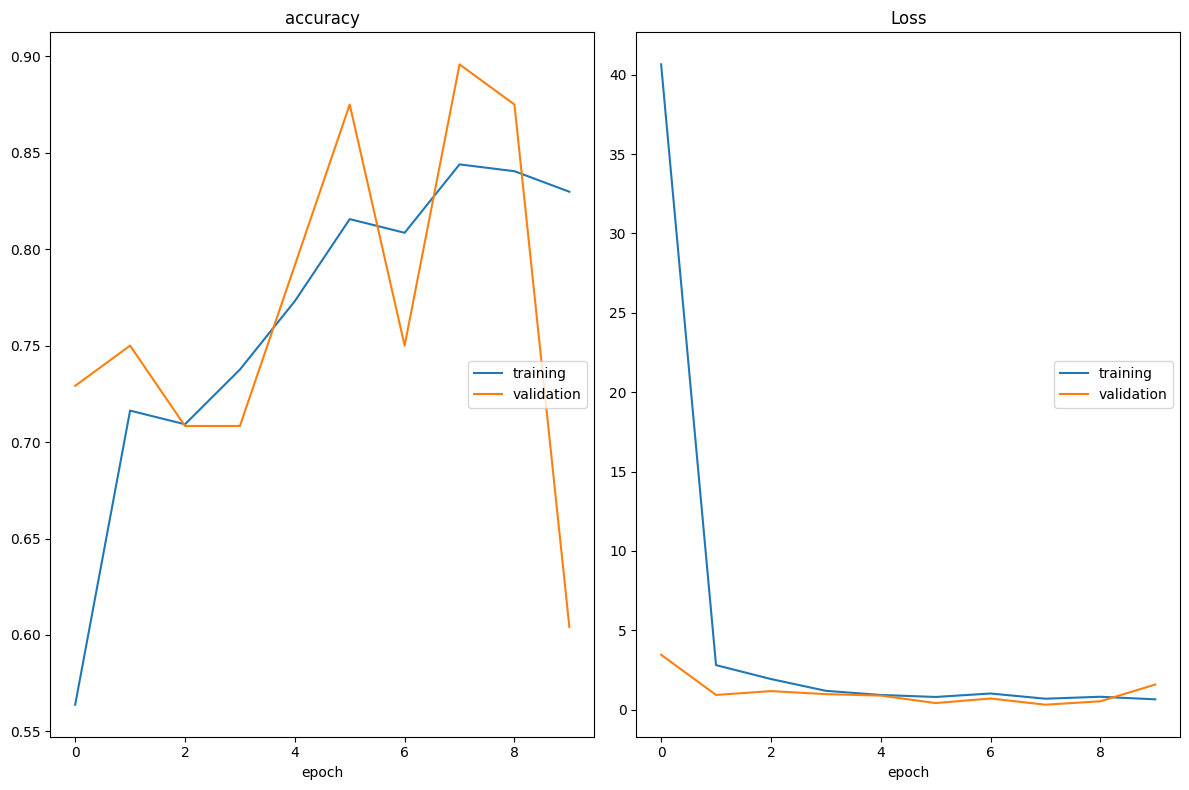

accuracy
	training         	 (min:    0.564, max:    0.844, cur:    0.830)
	validation       	 (min:    0.604, max:    0.896, cur:    0.604)
Loss
	training         	 (min:    0.649, max:   40.653, cur:    0.649)
	validation       	 (min:    0.311, max:    3.459, cur:    1.582)
36/36 [==============================] - 50s 1s/step - loss: 0.6492 - accuracy: 0.8298 - val_loss: 1.5821 - val_accuracy: 0.6042
CPU times: user 8min, sys: 55.4 s, total: 8min 56s
Wall time: 12min 22s


In [ ]:
%%time

vgg_history = vgg_model.fit(traingen,
                            batch_size=BATCH_SIZE,
                            epochs=n_epochs,
                            validation_data=validgen,
                            steps_per_epoch=n_steps,
                            validation_steps=n_val_steps,
                            callbacks=[tl_checkpoint_1, early_stop, plot_loss_1],
                            verbose=1)

In [ ]:
# Generate predictions
vgg_model.load_weights('tl_model_v1.weights.best.hdf5') # initialize the best trained weights

true_classes = testgen.classes
class_indices = traingen.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

vgg_preds = vgg_model.predict(testgen)
vgg_pred_classes = np.argmax(vgg_preds, axis=1)

87/87 [==============================] - 67s 758ms/step


In [ ]:
from sklearn.metrics import accuracy_score

vgg_acc = accuracy_score(true_classes, vgg_pred_classes)
print("VGG16 Model Accuracy without Fine-Tuning: {:.2f}%".format(vgg_acc * 100))

VGG16 Model Accuracy without Fine-Tuning: 85.06%


## Using Pre-trained Layers for Fine-Tuning

In [ ]:
# Reset our image data generators
traingen.reset()
validgen.reset()
testgen.reset()

# Use a smaller learning rate
optim_2 = Adam(lr=0.0001)

# Re-compile the model, this time leaving the last 2 layers unfrozen for Fine-Tuning
vgg_model_ft = create_model(input_shape, n_classes, optim_2, fine_tune=2)

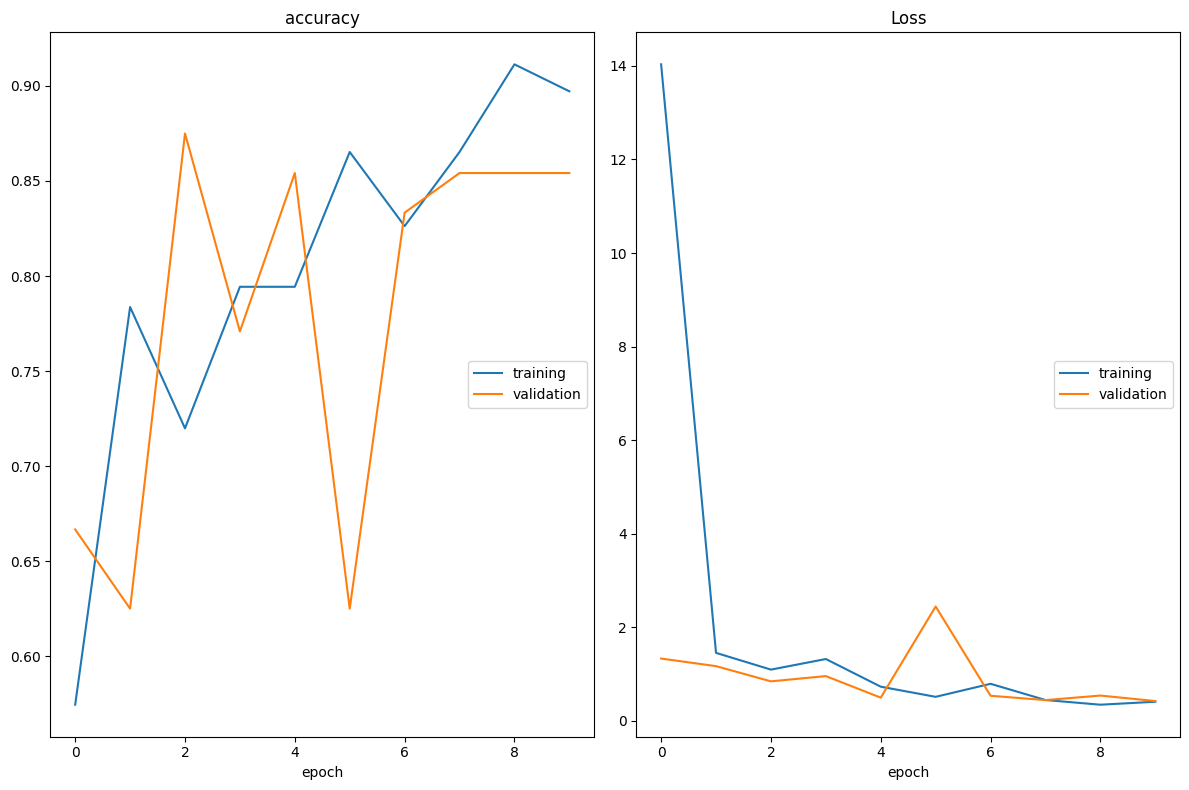

accuracy
	training         	 (min:    0.574, max:    0.911, cur:    0.897)
	validation       	 (min:    0.625, max:    0.875, cur:    0.854)
Loss
	training         	 (min:    0.340, max:   14.034, cur:    0.404)
	validation       	 (min:    0.418, max:    2.440, cur:    0.418)
36/36 [==============================] - 334s 9s/step - loss: 0.4036 - accuracy: 0.8972 - val_loss: 0.4184 - val_accuracy: 0.8542
CPU times: user 1h 13min 1s, sys: 11min 2s, total: 1h 24min 4s
Wall time: 58min 44s


In [ ]:
%%time

plot_loss_2 = PlotLossesCallback()

# Retrain model with fine-tuning
vgg_ft_history = vgg_model_ft.fit(traingen,
                                  batch_size=BATCH_SIZE,
                                  epochs=n_epochs,
                                  validation_data=validgen,
                                  steps_per_epoch=n_steps,
                                  validation_steps=n_val_steps,
                                  callbacks=[tl_checkpoint_1, early_stop, plot_loss_2],
                                  verbose=1)

In [ ]:
# Generate predictions
vgg_model_ft.load_weights('tl_model_v1.weights.best.hdf5') # initialize the best trained weights

vgg_preds_ft = vgg_model_ft.predict(testgen)
vgg_pred_classes_ft = np.argmax(vgg_preds_ft, axis=1)

87/87 [==============================] - 13s 149ms/step


In [ ]:
vgg_acc_ft = accuracy_score(true_classes, vgg_pred_classes_ft)
print("VGG16 Model Accuracy with Fine-Tuning: {:.2f}%".format(vgg_acc_ft * 100))

VGG16 Model Accuracy with Fine-Tuning: 85.06%


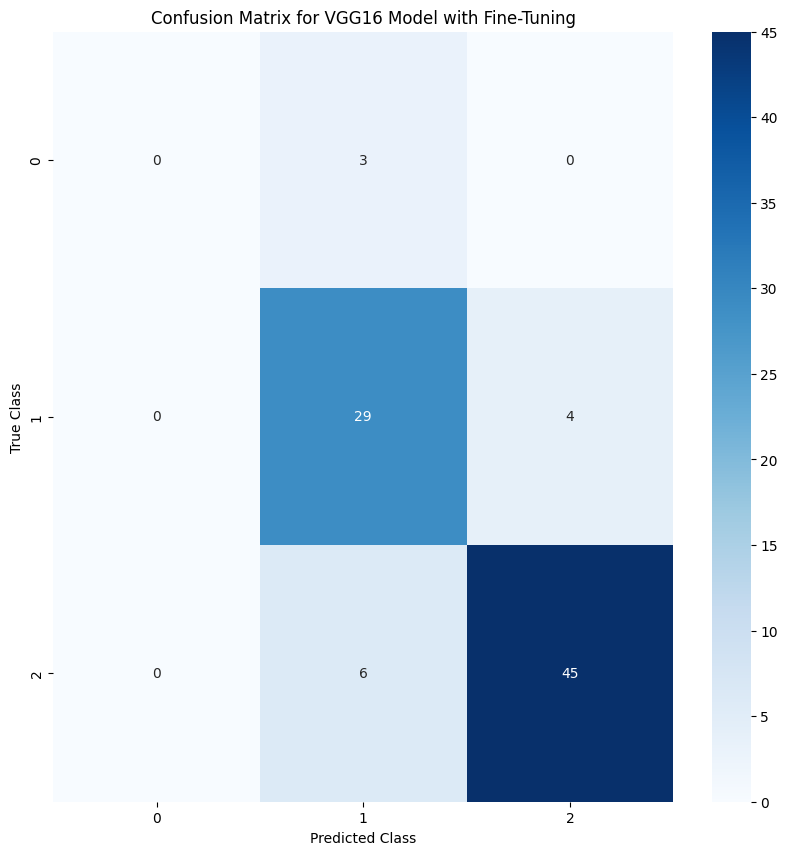

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


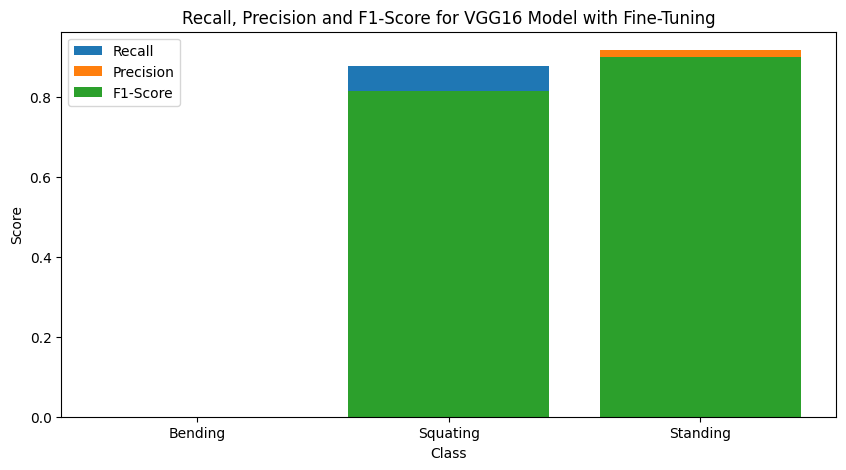

In [ ]:
# prompt: give code to generate confusion matrix , recall, precision and f1-score for every class in graph format

from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(true_classes, vgg_pred_classes_ft)

# Plot confusion matrix
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix for VGG16 Model with Fine-Tuning")
plt.show()

# Calculate recall, precision and f1-score for each class
recall = recall_score(true_classes, vgg_pred_classes_ft, average=None)
precision = precision_score(true_classes, vgg_pred_classes_ft, average=None)
f1 = f1_score(true_classes, vgg_pred_classes_ft, average=None)

print(recall)
print(precision)
print(f1)

# Plot recall, precision and f1-score for each class
plt.figure(figsize=(10, 5))
plt.bar(class_subset, recall, label="Recall")
plt.bar(class_subset, precision, label="Precision")
plt.bar(class_subset, f1, label="F1-Score")
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Recall, Precision and F1-Score for VGG16 Model with Fine-Tuning")
plt.legend()
plt.show()
